In [143]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
sys.path.append(os.path.abspath(".."))
from collector.database import Database

In [144]:
database = Database()
records = database.select_query()
df = pd.DataFrame(records, columns=["date", "current_time", "cpu_usage", "cpu_freq", "cpu_switches", "memory_usage",
                                    "memory_swap", "disk_usage", "read_write", "net", "bytes_sent", "bytes_recv",
                                    "battery_percent", "power_plugged", "gpu_usage", "gpu_temp",
                                    "top5_processes_cpu_average", "top5_processes_cpu_std","id"])

In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16475 entries, 0 to 16474
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        16475 non-null  str    
 1   current_time                16475 non-null  str    
 2   cpu_usage                   16475 non-null  float64
 3   cpu_freq                    16475 non-null  float64
 4   cpu_switches                16475 non-null  int64  
 5   memory_usage                16475 non-null  float64
 6   memory_swap                 16475 non-null  float64
 7   disk_usage                  16475 non-null  float64
 8   read_write                  16475 non-null  int64  
 9   net                         16475 non-null  int64  
 10  bytes_sent                  16475 non-null  int64  
 11  bytes_recv                  16475 non-null  int64  
 12  battery_percent             16475 non-null  int64  
 13  power_plugged               16475 non-null

In [146]:
df["cpu_usage"].describe().T

count    16475.000000
mean        10.489323
std          7.936279
min          0.300000
25%          4.900000
50%          8.600000
75%         13.800000
max        100.000000
Name: cpu_usage, dtype: float64

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16475 entries, 0 to 16474
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        16475 non-null  str    
 1   current_time                16475 non-null  str    
 2   cpu_usage                   16475 non-null  float64
 3   cpu_freq                    16475 non-null  float64
 4   cpu_switches                16475 non-null  int64  
 5   memory_usage                16475 non-null  float64
 6   memory_swap                 16475 non-null  float64
 7   disk_usage                  16475 non-null  float64
 8   read_write                  16475 non-null  int64  
 9   net                         16475 non-null  int64  
 10  bytes_sent                  16475 non-null  int64  
 11  bytes_recv                  16475 non-null  int64  
 12  battery_percent             16475 non-null  int64  
 13  power_plugged               16475 non-null

In [148]:
string = df.select_dtypes(include=["object"]).columns.to_list()

C:\Users\victus\AppData\Local\Temp\ipykernel_19788\539708080.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string = df.select_dtypes(include=["object"]).columns.to_list()


In [149]:
string

['date', 'current_time']

In [150]:
df["power_plugged"] = df["power_plugged"].astype(int)

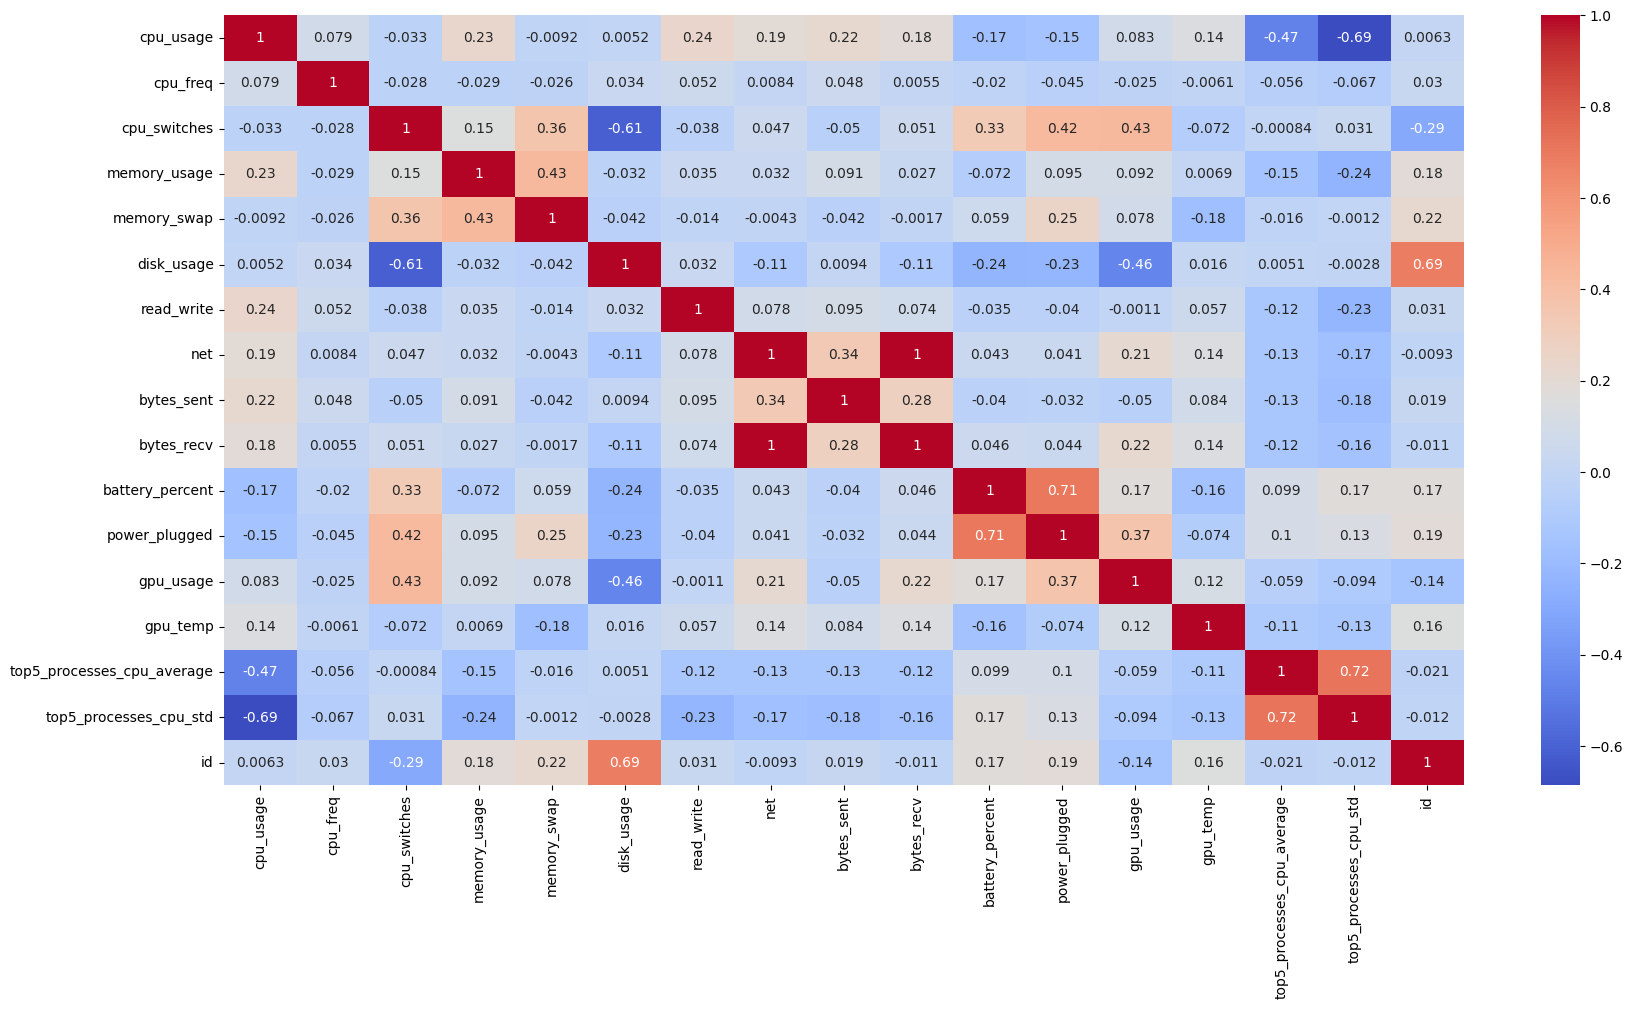

In [151]:
df.corr(numeric_only=True)
fig ,ax = plt.subplots(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=ax, cmap="coolwarm")
plt.show()


In [152]:
# # Convert date to datetime
# df['data'] = pd.to_datetime(df['data'])

# # Convert time to datetime and extract components
# df['current_time'] = pd.to_datetime(df['current_time'], format='%H:%M:%S').dt.time
# df['hour'] = pd.to_datetime(df['current_time'].astype(str)).dt.hour
# df['minute'] = pd.to_datetime(df['current_time'].astype(str)).dt.minute
# df['second'] = pd.to_datetime(df['current_time'].astype(str)).dt.second

# # Optional: cyclical encoding for hour, minute, second
# df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
# df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

# df['minute_sin'] = np.sin(2 * np.pi * df['minute']/60)
# df['minute_cos'] = np.cos(2 * np.pi * df['minute']/60)

# df['second_sin'] = np.sin(2 * np.pi * df['second']/60)
# df['second_cos'] = np.cos(2 * np.pi * df['second']/60)

# # Extract day/month from date
# df['day'] = df['data'].dt.day
# df['month'] = df['data'].dt.month

# # Drop original date/time columns
# df = df.drop(columns=['data', 'current_time', 'hour', 'minute', 'second'])

In [153]:
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["current_time"])

In [154]:
df["time_window"] = df["timestamp"].dt.floor("1min")  

In [155]:
featured_columns = ["cpu_usage", "memory_usage","top5_processes_cpu_average","top5_processes_cpu_std"]
WINDOW = 10

In [156]:
# for feature in featured_columns:
#     df[f"{feature}_mean"] = (
#         df.groupby("time_window")[feature]
#         .rolling(window=WINDOW,min_periods=3)
#         .mean()
#         .reset_index(level=0,drop=True)   
#     )

In [157]:
# for feature in featured_columns:
#     df[f"{feature}_std"] = (
#         df.groupby("time_window")[feature]
#         .rolling(window=WINDOW,min_periods=3)
#         .std()
#         .reset_index(level=0,drop=True)
#     )

In [158]:
df = df.sort_values("timestamp")

In [159]:
df["time_diff"] = df["timestamp"].diff().dt.total_seconds()

In [160]:
df["new_session"] = (df["time_diff"]>60).astype(int)

In [161]:
df["session_id"] = df["new_session"].cumsum()

In [162]:
for feature in featured_columns:
    df[f"{feature}_sess_mean"] = (
        df.groupby("session_id")[feature]
        .rolling(window=WINDOW)
        .mean()
        .reset_index(level=0,drop=True)   
    )

In [163]:
for feature in featured_columns:
    df[f"{feature}_sess_std"] = (
        df.groupby("session_id")[feature]
        .rolling(window=WINDOW)
        .std()
        .reset_index(level=0,drop=True)
    )

In [164]:
df["cpu_spike_diff"] = df.groupby("session_id")["cpu_usage"].diff()
df["memory_spike_diff"] = df.groupby("session_id")["memory_usage"].diff()

In [165]:
df["session_id"].value_counts()


session_id
8     2780
20    2733
9     1309
2     1200
21    1156
19    1121
5      914
12     800
0      753
3      750
6      454
25     408
11     372
7      333
14     325
4      147
1      137
34     137
32     108
26      87
24      86
31      82
33      65
22      53
13      50
23      27
27      20
28      20
29      20
30      14
16       5
15       3
17       3
10       2
18       1
Name: count, dtype: int64

In [166]:
df = df.dropna()

In [167]:
X = df.drop(columns=["date","current_time","time_window","timestamp","new_session","new_session","session_id","id"])


In [168]:
def feature_engineering(df):
    featured_columns = ["cpu_usage", "memory_usage","gpu_usage","top5_processes_cpu_average","top5_processes_cpu_std"]
    WINDOW = 5

    df["timestamp"] = pd.to_datetime(df["date"] + " " + df["current_time"])
    df["time_window"] = df["timestamp"].dt.floor("1min")  
    df = df.sort_values("timestamp")
    df["time_diff"] = df["timestamp"].diff().dt.total_seconds()
    df["new_session"] = (df["time_diff"]>60).astype(int)
    df["session_id"] = df["new_session"].cumsum()

    for feature in featured_columns:
        df[f"{feature}_sess_mean"] = (
            df.groupby("session_id")[feature]
            .rolling(window=WINDOW)
            .mean()
            .reset_index(level=0,drop=True)   
        )

    for feature in featured_columns:
        df[f"{feature}_sess_std"] = (
            df.groupby("session_id")[feature]
            .rolling(window=WINDOW)
            .std()
            .reset_index(level=0,drop=True)
        )

    df["cpu_spike_diff"] = df.groupby("session_id")["cpu_usage"].diff()
    df["memory_spike_diff"] = df.groupby("session_id")["memory_usage"].diff()
    df["gpu_spike_diff"] = df.groupby("session_id")["gpu_usage"].diff()
    df = df.drop(columns=["date","current_time","time_window","timestamp","new_session","new_session","session_id"])

    return df

In [169]:
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

In [170]:
model = IsolationForest(contamination=0.01,n_estimators=500,random_state=42)
model.fit(scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",500
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [171]:
score_prediction = model.decision_function(scaled)


In [172]:
scores = model.decision_function(scaled)


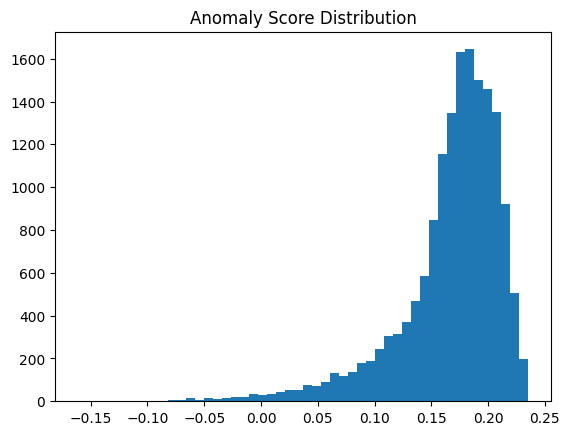

In [173]:
plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.show()

In [174]:
threshold = np.percentile(scores,0.1)
df["anomaly"] = (scores < threshold).astype(int)

In [175]:
a = df[df["anomaly"] == 1][["cpu_usage"]]
a.describe()

,cpu_usage
count,17.000000
mean,47.047059
std,25.647079
min,14.400000
25%,23.300000
50%,48.400000
75%,56.400000
max,100.000000


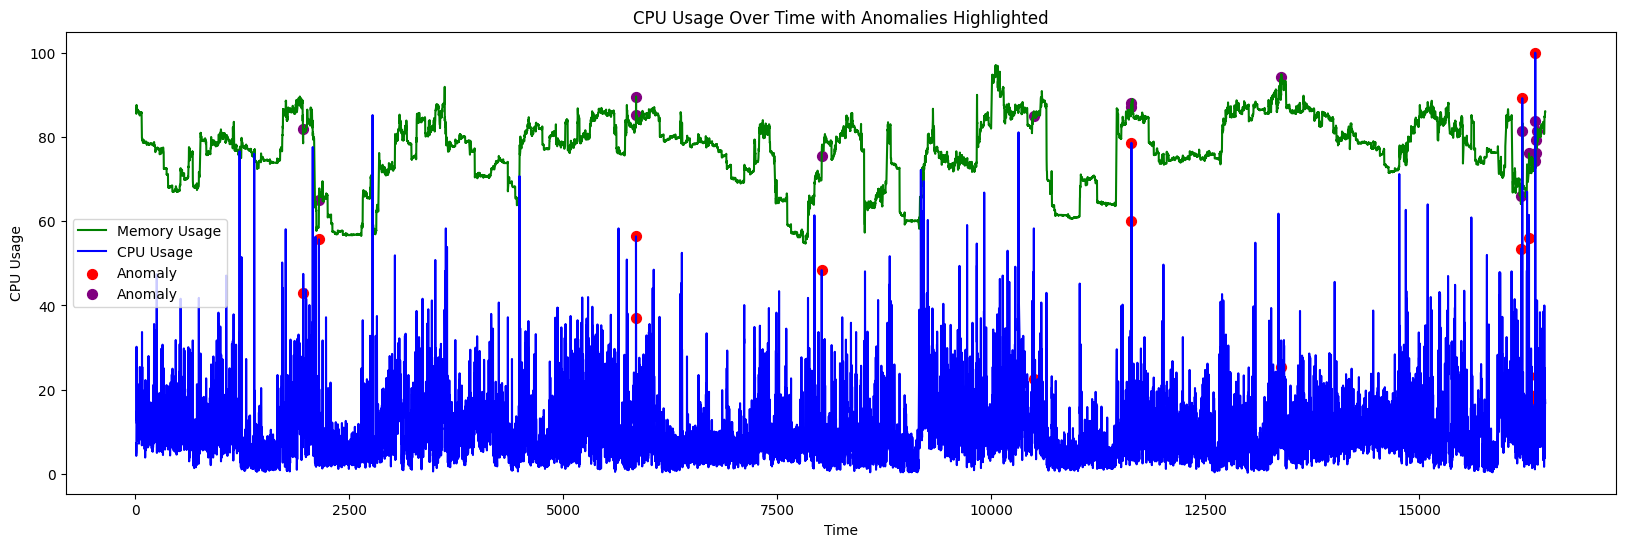

In [176]:
import matplotlib.pyplot as plt

df['data_time'] = pd.to_datetime(df.index)  

plt.figure(figsize=(20,6))
plt.plot(df.index, df['memory_usage'], label='Memory Usage', color='green')
plt.plot(df.index, df['cpu_usage'], label='CPU Usage', color='blue')

# Mark anomalies
anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['cpu_usage'], color='red', label='Anomaly', s=50)
plt.scatter(anomalies.index, anomalies['memory_usage'], color='purple', label='Anomaly', s=50)


plt.xlabel('Time')
plt.ylabel('CPU Usage')
plt.title('CPU Usage Over Time with Anomalies Highlighted')
plt.legend()
plt.show()

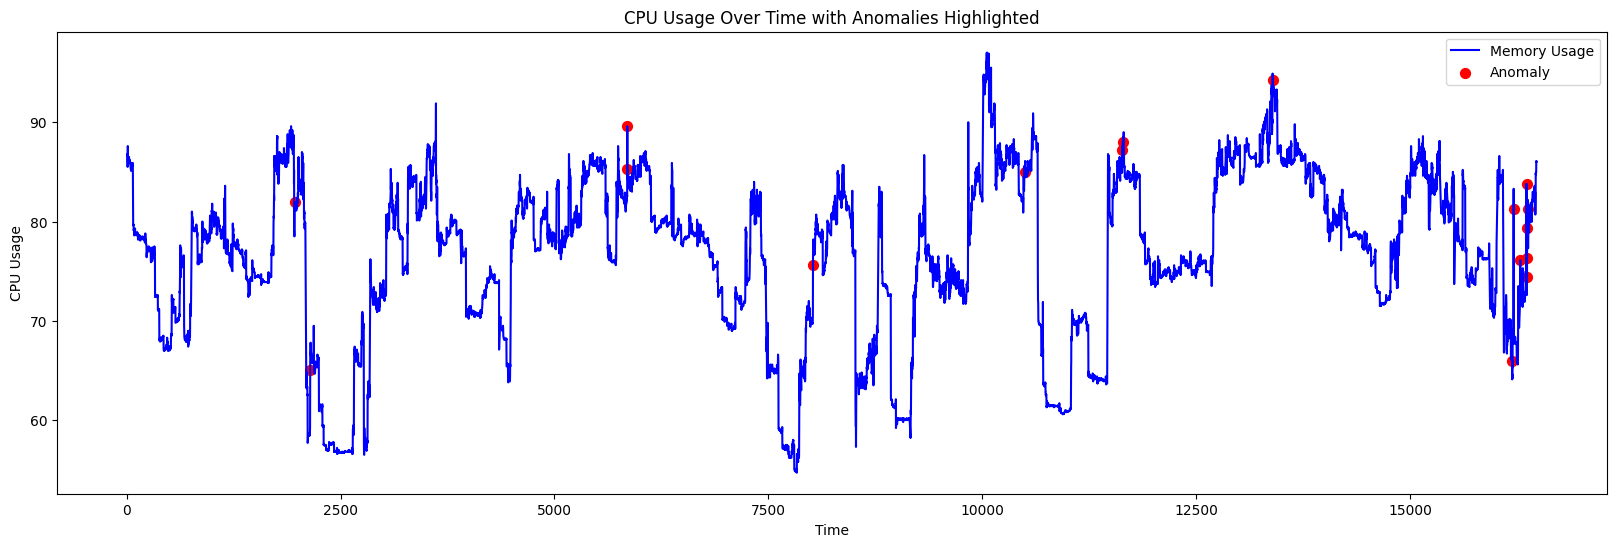

In [177]:
import matplotlib.pyplot as plt

df['data_time'] = pd.to_datetime(df.index)  

plt.figure(figsize=(20,6))
plt.plot(df.index, df['memory_usage'], label='Memory Usage', color='blue')

# Mark anomalies
anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['memory_usage'], color='red', label='Anomaly', s=50)

plt.xlabel('Time')
plt.ylabel('CPU Usage')
plt.title('CPU Usage Over Time with Anomalies Highlighted')
plt.legend()
plt.show()

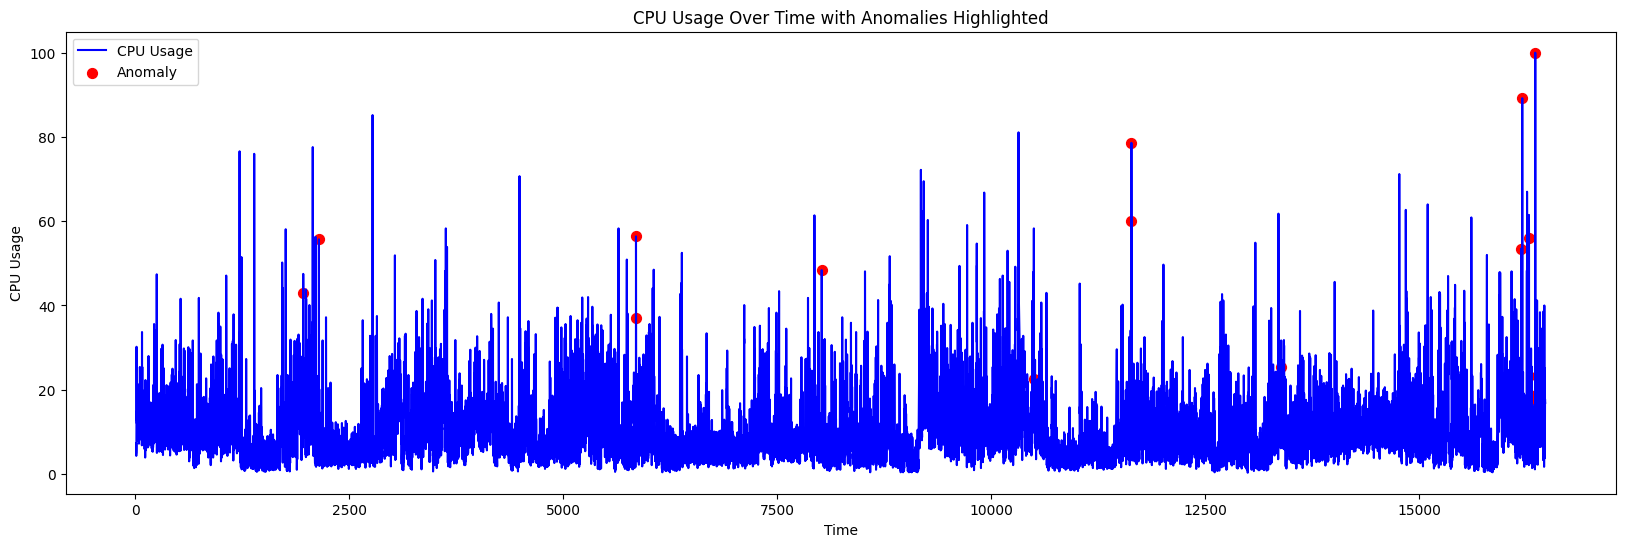

In [178]:

df['data_time'] = pd.to_datetime(df.index)  

plt.figure(figsize=(20,6))

plt.plot(df.index, df['cpu_usage'], label='CPU Usage', color='blue')

# Mark anomalies
anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['cpu_usage'], color='red', label='Anomaly', s=50)

plt.xlabel('Time')
plt.ylabel('CPU Usage')
plt.title('CPU Usage Over Time with Anomalies Highlighted')
plt.legend()
plt.show()

In [179]:
import joblib
joblib.dump(model, "isolation_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']